# Statistical Machine Learning: From Gradients to Generative AI

## 1. The Optimization Objective
In statistical learning, we aim to find a function $f_\theta$ that maps inputs $x$ to targets $y$. We define a **Loss Function** $\mathcal{L}$ that measures the discrepancy between our prediction and the truth. Our goal is to find the parameters $\theta$ that minimize the average loss across our dataset:

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}(y_i, f_\theta(x_i))$$

While classical models like Decision Trees or Support Vector Machines are powerful for tabular data, they often struggle with the high-dimensional, non-linear patterns found in text or images.

## 2. Neural Networks and the MLP
To process highly complex data, we transition to Neural Networks. These models solve the representation problem by stacking simple mathematical operations to create a highly flexible, trainable system. The most foundational architecture is the **Multi-Layer Perceptron (MLP)**.

An MLP consists of interconnected nodes (neurons) organized into layers: an input layer, one or more hidden layers, and an output layer. A single layer performs the following operation:

$$h = \sigma(Wx + b)$$

* **Linear Transformation ($Wx + b$):** The model multiplies the input vector $x$ by a weight matrix $W$ and adds a bias vector $b$. This projects the data into a new mathematical space.
* **The Activation Function ($\sigma$):** This introduces non-linearity. Without it, stacking multiple layers would collapse mathematically into a single linear transformation. Popular activation functions include:
    * **Sigmoid / Tanh:** Historically used to squash outputs between specific bounds.
    * **ReLU (Rectified Linear Unit):** $\max(0, x)$. The standard default due to its computational efficiency and strong gradient propagation.
    * **GELU (Gaussian Error Linear Unit):** A smoother version of ReLU heavily used in modern Transformers (like GPT models).

### The Universal Approximation Theorem
The theoretical foundation of these models rests on the Universal Approximation Theorem. It states that a neural network with at least one hidden layer and a non-linear activation function can approximate any continuous function to an arbitrary degree of accuracy, provided it has enough neurons.

### The Shift to Deep Learning

![asdf](assets/deep_NN.png)

If one hidden layer can approximate anything, why do we use Deep Learning? A single, infinitely wide hidden layer is mathematically valid but practically impossible to train and prone to severe overfitting. 

Instead of making networks wider, we make them deeper. Deep Learning leverages multiple hidden layers to learn hierarchical representations. For instance, in visual tasks, early layers learn simple edges, middle layers learn shapes, and deeper layers learn complex objects. This hierarchical approach led to the modern architectures dominating AI today:
* **CNNs (Convolutional Neural Networks):** Exploit deep layers to learn spatial hierarchies in images.
* **Transformers:** Exploit deep layers of Self-Attention to learn hierarchical contextual relationships in sequential data (like language).

## 3. The Baseline: Manual Gradient Descent
To train any of these models, we must update our parameters $\theta$ to reduce the loss. We do this by calculating the **Gradient** ($\nabla_\theta \mathcal{L}$), which points in the direction of steepest ascent of the loss surface. We then take a small step in the opposite direction.

For a simple Linear Regression problem, the formulation is:
* **Hypothesis:** $\hat{y} = X\theta$
* **Loss (Mean Squared Error):** $\mathcal{L}(\theta) = \frac{1}{N} \|X\theta - y\|^2$

Taking the derivative of the loss with respect to the parameters gives us the exact analytical gradient:

$$\nabla_\theta \mathcal{L} = \frac{2}{N} X^T (X\theta - y)$$

Let us implement this gradient descent update rule "the hard way" using NumPy. 

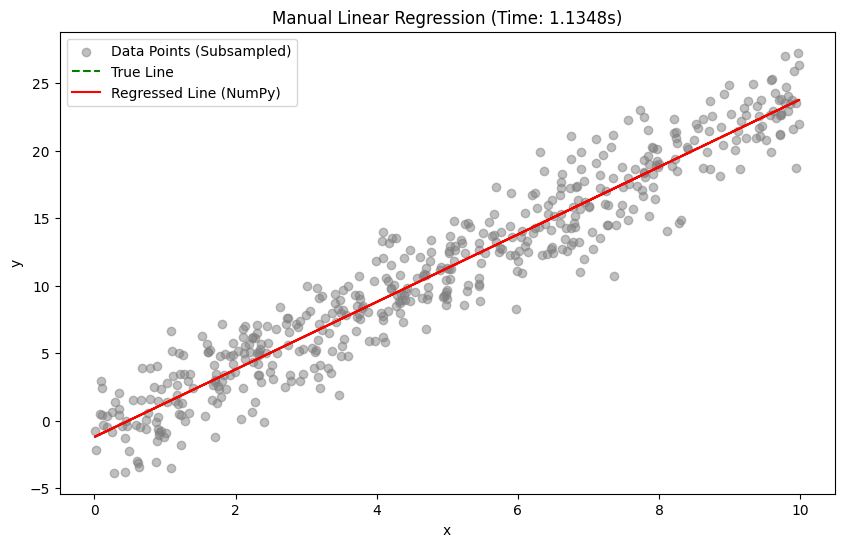

Final Weights: w=2.50, b=-1.19
True Weights: w=2.5, b=-1.2
NumPy Training Time: 1.1348 seconds


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. Generate synthetic data (Scaled up to show computational time)
np.random.seed(42)
N = 1_000_000
X = np.random.rand(N, 1) * 10 
true_w, true_b = 2.5, -1.2
y = true_w * X + true_b + np.random.randn(N, 1) * 2

# 2. Initialize parameters
w_np = np.random.randn(1, 1)
b_np = np.zeros(1)
learning_rate = 0.02
epochs = 500

# 3. Manual Gradient Descent Loop
start_time = time.time()
for epoch in range(epochs):
    # Forward pass: compute predictions
    y_pred = X.dot(w_np) + b_np
    
    # Compute gradients (Manual Calculus)
    error = y_pred - y
    grad_w = (2/N) * X.T.dot(error)
    grad_b = (2/N) * np.sum(error)
    
    # Update weights
    w_np -= learning_rate * grad_w
    b_np -= learning_rate * grad_b

# Store time in a variable for later comparison
numpy_training_time = time.time() - start_time

# 4. Visualization (Subsampling for plotting efficiency)
plot_indices = np.random.choice(N, size=500, replace=False)
X_plot = X[plot_indices]
y_plot = y[plot_indices]

plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_plot, color='gray', alpha=0.5, label='Data Points (Subsampled)')
plt.plot(X_plot, true_w * X_plot + true_b, color='green', linestyle='--', label='True Line')
plt.plot(X_plot, w_np * X_plot + b_np, color='red', label='Regressed Line (NumPy)')
plt.title(f"Manual Linear Regression (Time: {numpy_training_time:.4f}s)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"Final Weights: w={w_np.item():.2f}, b={b_np.item():.2f}")
print(f"True Weights: w={true_w}, b={true_b}")
print(f"NumPy Training Time: {numpy_training_time:.4f} seconds")

## 4. Enter PyTorch: Tensors and Hardware Acceleration
While NumPy is fantastic for general-purpose numerical computing, it lacks two critical features needed for Deep Learning: native GPU acceleration and automatic differentiation. PyTorch solves both problems through its core data structure: the **Tensor**.

Tensors are nearly identical to NumPy arrays, but they can be seamlessly moved to specialized hardware accelerators. Modern PyTorch supports multiple devices:
* **CPU:** The default, but often a bottleneck for large matrix multiplications.
* **CUDA:** For NVIDIA GPUs, the industry standard for deep learning acceleration.
* **MPS:** (Metal Performance Shaders) For Apple Silicon Macs, allowing hardware acceleration on local machines.

In [2]:
import torch

# Create a simple tensor from a NumPy array
x_numpy = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)
x_tensor = torch.tensor(x_numpy)

print(f"Tensor:\n{x_tensor}")
print(f"Default Device: {x_tensor.device}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"\nSelected Hardware Accelerator: {device}")

# Move the tensor to the available accelerator
x_tensor_device = x_tensor.to(device)
print(f"Tensor is now located on {x_tensor_device.device}")

Tensor:
tensor([[1., 2.],
        [3., 4.]])
Default Device: cpu

Selected Hardware Accelerator: mps
Tensor is now located on mps:0


## 5. The Magic of Autograd
The second superpower of PyTorch is `autograd`, its automatic differentiation engine. By simply setting `requires_grad=True` on a tensor, PyTorch begins tracking every mathematical operation performed on it, dynamically building a computational graph in the background.



Let us test it on a simple function where we know the analytical derivative:
$$f(x) = 3x^2 + 2x$$

The mathematical derivative is:
$$f'(x) = 6x + 2$$

If we evaluate this at $x = 2$, the function value is $f(2) = 16$, and the gradient is $f'(2) = 14$. Let us see if PyTorch calculates this automatically.

In [3]:
# Define a tensor with a value of 2.0 and tell PyTorch to track gradients
x = torch.tensor(2.0, requires_grad=True)

# Define the simple mathematical function
z = 3 * x**2 + 2 * x

# Trigger the autograd engine to compute the derivative backward from z
z.backward()

# The gradient dz/dx is now stored automatically inside x.grad
print(f"Calculated Gradient (dz/dx): {x.grad.item()}")

Calculated Gradient (dz/dx): 14.0


## 6. The Chain Rule and Deep Networks
A Neural Network is essentially a massive composition of mathematical functions. Layer 1 feeds into Layer 2, which feeds into Layer 3, and finally into the loss function. To train the network, we need the derivative of the loss with respect to the weights of the very first layer.

Mathematically, this is solved using the **Chain Rule**. PyTorch's `autograd` handles this flawlessly. Let us define a composition of three simple functions:
1. $a(x) = 2x$
2. $b(a) = a^2$
3. $c(b) = 3b$

The composite function is $c(x) = 3(2x)^2 = 12x^2$. 
The derivative is $c'(x) = 24x$. 
At $x = 2$, the gradient must be $48$. Let us demonstrate how PyTorch tracks gradients sequentially through these steps.

In [4]:
# Initialize input tensor
x = torch.tensor(2.0, requires_grad=True)

# Apply Function 1
a = 2 * x

# Apply Function 2
b = a**2

# Apply Function 3 (This acts like our final "loss" value)
c = 3 * b

# Backpropagate through the entire chain of functions
c.backward()

print(f"Gradient after chain rule (dc/dx): {x.grad.item()}")

Gradient after chain rule (dc/dx): 48.0


### Why This Matters for Deep Learning
This exact mechanism is how Deep Learning models train. No matter how many linear layers, activation functions, or attention mechanisms you stack together, PyTorch builds a graph of the forward pass. When you call `.backward()` on your final loss value, PyTorch traverses that graph in reverse, applying the chain rule at every step to calculate the gradient for every single parameter. We can now use these gradients to implement Gradient Descent without writing any manual calculus!

## 7. Building Models the PyTorch Way (`nn.Module`)
In the previous section, we created individual tensors and set `requires_grad=True`. For a deep neural network, managing millions of individual weight and bias tensors this way would be a nightmare.

PyTorch solves this with the `torch.nn` module. This library provides pre-built, optimized building blocks for neural networks. 
* **`nn.Module`:** The base class for all neural network models. It automatically keeps track of all parameters inside it.
* **Pre-built Layers:** PyTorch provides ready-to-use layers like `nn.Linear` (for MLPs), `nn.Conv2d` (for images), and `nn.Transformer` (for language).



When building a model, we always subclass `nn.Module` and define two methods:
1. `__init__`: Where we define our layers.
2. `forward`: Where we define how the input data passes through those layers.

Let us define our Linear Regression model using these tools.

In [5]:
import torch.nn as nn

# Define the model architecture
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # nn.Linear automatically creates the weight and bias tensors
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # The forward pass is just applying the linear layer to the input
        return self.linear(x)

# Instantiate the model (1 feature in, 1 prediction out)
model = LinearRegressionModel(input_dim=1, output_dim=1)

# Move the model's parameters to our hardware accelerator (GPU or MPS)
model.to(device)

print(model)
print("\nModel parameters being tracked:")
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}, requires_grad={param.requires_grad}")

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Model parameters being tracked:
linear.weight: torch.Size([1, 1]), requires_grad=True
linear.bias: torch.Size([1]), requires_grad=True


## 8. Loss Functions and Optimizers
Instead of writing the mathematical formula for Mean Squared Error manually, PyTorch provides it out of the box. 

Similarly, instead of writing the update rule `w -= learning_rate * gradient`, PyTorch provides **Optimizers** in `torch.optim`. The optimizer takes the model's parameters and handles the update step automatically. This becomes crucial when using advanced optimization algorithms like Adam or RMSprop.

### The 5-Step PyTorch Training Loop
Every PyTorch training loop follows the exact same five steps, whether you are training a linear regression model or a billion-parameter LLM:
1. **Clear Gradients:** PyTorch accumulates gradients by default. We must clear them before each step.
2. **Forward Pass:** Pass the data through the model to get predictions.
3. **Calculate Loss:** Compare predictions to the true targets.
4. **Backward Pass:** Trigger `autograd` to compute the gradients.
5. **Optimizer Step:** Update the weights using the calculated gradients.

Let us run our previous point dataset through this PyTorch loop and time it.

In [6]:
import torch.optim as optim
import time

# 1. Prepare the Data
# Convert our existing 1-million point NumPy arrays to PyTorch Tensors.
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).to(device)

# 2. Define Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.02)

epochs = 500

# 3. The Training Loop
start_time = time.time()

for epoch in range(epochs):
    # Step 1: Clear old gradients
    optimizer.zero_grad()
    
    # Step 2: Forward pass
    predictions = model(X_tensor)
    
    # Step 3: Calculate the loss
    loss = criterion(predictions, y_tensor)
    
    # Step 4: Backward pass (compute gradients)
    loss.backward()
    
    # Step 5: Update the parameters
    optimizer.step()

pytorch_training_time = time.time() - start_time

# 4. Results and Comparison
print(f"PyTorch Training Time: {pytorch_training_time:.4f} seconds")
print(f"NumPy Training Time (Baseline): {numpy_training_time:.4f} seconds")

speedup = numpy_training_time / pytorch_training_time
print(f"\nHardware Acceleration Speedup: {speedup:.2f}x")

# Extract final weights to verify the model learned correctly
final_w = model.linear.weight.item()
final_b = model.linear.bias.item()
print(f"\nFinal PyTorch Weights: w={final_w:.2f}, b={final_b:.2f}")
print(f"Final NumPy Weights: w={w_np.item():.2f}, b={b_np.item():.2f}")
print(f"True Weights: w={true_w}, b={true_b}")

PyTorch Training Time: 0.6814 seconds
NumPy Training Time (Baseline): 1.1348 seconds

Hardware Acceleration Speedup: 1.67x

Final PyTorch Weights: w=2.50, b=-1.19
Final NumPy Weights: w=2.50, b=-1.19
True Weights: w=2.5, b=-1.2


## 9. Categorical Probability and The Danger of "Optimism"
We are no longer predicting a single continuous number. Identifying a handwritten digit (or predicting the next word in a sentence) is a **Classification** problem. Our model must output a probability distribution across all possible categories. To optimize this, we switch our loss function from Mean Squared Error to **Cross-Entropy Loss**, which measures the divergence between our predicted probabilities and the true label.

### The Statistical "Optimism" of Training
When optimizing these probabilities, we run into a fundamental issue: **Optimism**. The error we calculate on our training data ($Err_{train}$) is an optimistic, downward-biased estimate of how the model will perform on new data ($Err_{test}$). 

$$\text{Optimism} = Err_{test} - Err_{train}$$

Neural networks are incredibly powerful function approximators. If a network has enough parameters, it will simply memorize the training data. The training loss will approach zero, but the model will fail entirely on unseen data. This is called **Overfitting**.

### Validation Set, Test Set, and Hyperparameters
To manage optimism and build models that generalize, we split our data into three distinct buckets:
1. **Training Set:** The data the model physically learns from (where gradients are calculated).
2. **Validation Set:** A holdout set used *during* training to monitor the "true" performance. We use this set to tune our **Hyperparameters** (architectural choices we make before training, like learning rate, number of layers, or regularization strength).
3. **Test Set:** The ultimate vault. It is locked away and evaluated *only once* at the very end. If you tweak your model based on Test Set performance, you leak data, and it essentially becomes a second Validation Set.

### DataLoaders and PyTorch Lightning
Writing the manual loops to handle training, validation tracking, and device management involves a lot of boilerplate. We will use a crucial PyTorch concept to solve this: the **`DataLoader`**. This is a utility that automatically batches, shuffles, and feeds our dataset into the model.

**PyTorch Lightning** is a lightweight framework that abstracts the `for` loops away, utilizing DataLoaders to handle hardware placement and validation automatically. 

Let us build a naive, over-parameterized Multi-Layer Perceptron (MLP). We will intentionally train it on a tiny subset of handwritten digits (MNIST) to visually demonstrate training optimism.

In [7]:
import torch.nn.functional as F
import lightning as L
from torch.utils.data import DataLoader, Subset
from data.MNIST.mnist_loader import MNIST 

# 1. Data Setup (100 samples for the "Textbook Overfit")
full_dataset = MNIST()
train_loader = DataLoader(Subset(full_dataset, range(100)), batch_size=50, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, range(100, 1000)), batch_size=100, shuffle=False)

# 2. The High-Capacity Model
class TextbookOverfitModel(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, 10)
        )
        # Dictionary to store our metrics for plotting
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def forward(self, x): 
        return self.net(x)

    def training_step(self, batch):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (torch.argmax(logits, dim=1) == y).float().mean()
        self.log_dict({'train_loss': loss, 'train_acc': acc})
        return loss

    def validation_step(self, batch):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (torch.argmax(logits, dim=1) == y).float().mean()
        self.log_dict({'val_loss': loss, 'val_acc': acc})

    def on_train_epoch_end(self):
        self.history['train_loss'].append(self.trainer.callback_metrics['train_loss'].item())
        self.history['train_acc'].append(self.trainer.callback_metrics['train_acc'].item())
        self.history['val_loss'].append(self.trainer.callback_metrics['val_loss'].item())
        self.history['val_acc'].append(self.trainer.callback_metrics['val_acc'].item())

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

# 3. Train the Naive Model
torch.manual_seed(1)
naive_model = TextbookOverfitModel()
trainer_naive = L.Trainer(max_epochs=10)
trainer_naive.fit(naive_model, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enabl

/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/pyt

Epoch 9: 100%|██████████| 2/2 [00:00<00:00, 28.21it/s, v_num=29] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 2/2 [00:00<00:00, 23.30it/s, v_num=29]


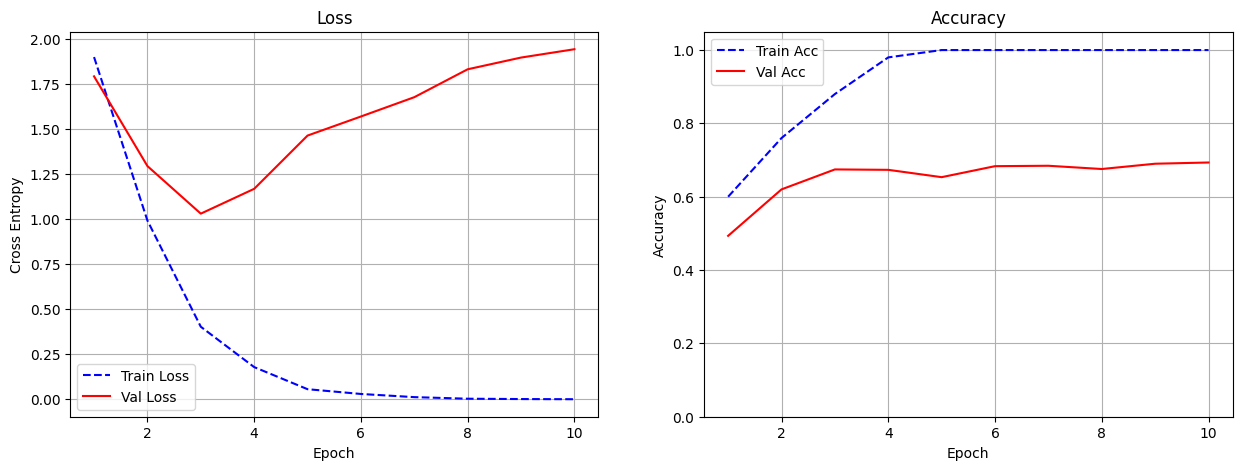

In [8]:
# Extract metrics
naive_metrics = naive_model.history
epochs = range(1, 11)

# Plot the Naive Curves
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax[0].plot(epochs, naive_metrics['train_loss'], 'b--', label='Train Loss')
ax[0].plot(epochs, naive_metrics['val_loss'], 'r-', label='Val Loss')
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Cross Entropy")
ax[0].legend()
ax[0].grid(True)

# Plot Accuracy
ax[1].plot(epochs, naive_metrics['train_acc'], 'b--', label='Train Acc')
ax[1].plot(epochs, naive_metrics['val_acc'], 'r-', label='Val Acc')
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0, 1.05)
ax[1].legend()
ax[1].grid(True)

plt.show()

### Decoding the Generalization Gap
Look closely at the two plots above. 
1. **The Accuracy Plateau:** The model hits around 70% accuracy on the validation set and stays there. The raw number of correct predictions stops improving.
2. **The Loss U-Turn:** Even though the accuracy is flat, the validation loss explodes upward. Why?

Because Cross-Entropy Loss measures **confidence**, not just correctness. As the model memorizes the 100 training images, it becomes overconfident. When it sees an unfamiliar validation image, it might still guess the correct class, but its mathematical confidence drops. Conversely, when it guesses wrong, it does so with extreme, misplaced certainty. This penalty causes the loss to diverge wildly, visually proving that the model is no longer generalizing.

### 10. Controlling Optimism with Regularization
To prevent this memorization, we introduce **Regularization**. Regularization constrains the network's capacity, forcing it to learn robust underlying patterns rather than memorizing noise. 

We will now train a second model identical to the first, but we will activate **Weight Decay** (L2 Regularization) inside the Adam optimizer. This adds a mathematical penalty for large parameter weights, keeping the network simple. Let us see how it aligns the curves.

explain weight decay with loss

In [9]:
# Inherit everything from your Naive model
class RegularizedOverfitModel(TextbookOverfitModel):
    def configure_optimizers(self):
        # We only redefine this part. 
        # Everything else (history, step logic, layers) is inherited.
        return torch.optim.Adam(
            self.parameters(), 
            lr=1e-3, 
            weight_decay=5e-2  # The only change
        )

# 1. Train the Regularized Model
torch.manual_seed(1)
reg_model = RegularizedOverfitModel()
trainer_reg = L.Trainer(max_epochs=10)
trainer_reg.fit(reg_model, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | net  | Sequential | 1.9 M  | train | 0    
----------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.455     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 9: 100%|██████████| 2/2 [00:00<00:00, 19.35it/s, v_num=30]            

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 2/2 [00:00<00:00, 15.66it/s, v_num=30]


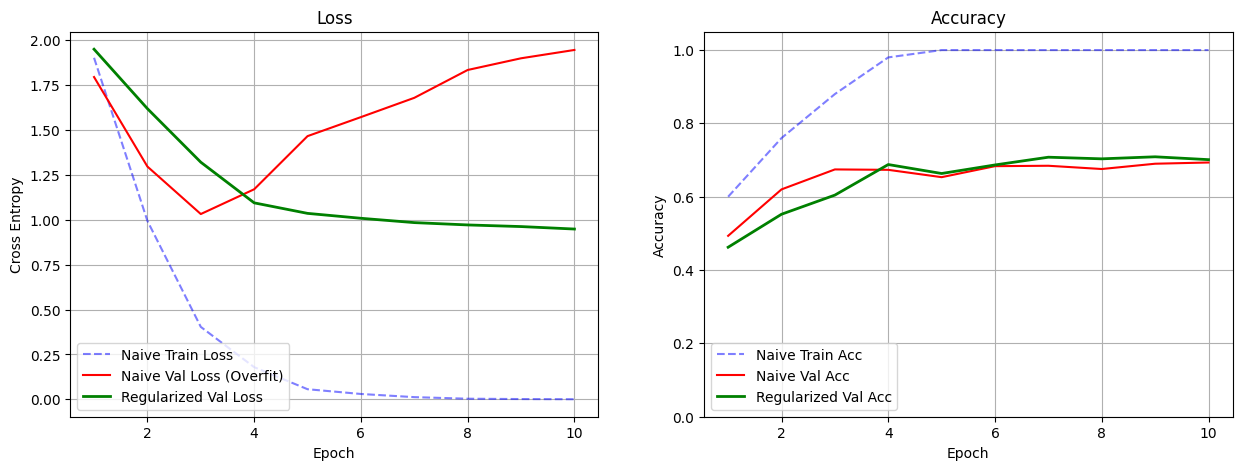

In [10]:
# Extract metrics
reg_metrics = reg_model.history

# Final Comparison Plots
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss Comparison
ax[0].plot(epochs, naive_metrics['train_loss'], 'b--', label='Naive Train Loss', alpha=0.5)
ax[0].plot(epochs, naive_metrics['val_loss'], 'r-', label='Naive Val Loss (Overfit)')
ax[0].plot(epochs, reg_metrics['val_loss'], 'g-', label='Regularized Val Loss', linewidth=2)
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Cross Entropy")
ax[0].legend()
ax[0].grid(True)

# Plot Accuracy Comparison
ax[1].plot(epochs, naive_metrics['train_acc'], 'b--', label='Naive Train Acc', alpha=0.5)
ax[1].plot(epochs, naive_metrics['val_acc'], 'r-', label='Naive Val Acc')
ax[1].plot(epochs, reg_metrics['val_acc'], 'g-', label='Regularized Val Acc', linewidth=2)
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0, 1.05)
ax[1].legend()
ax[1].grid(True)

plt.show()

## 11. Generative AI: The Small Language Model (SLM)
We have moved from predicting continuous values (Regression) to predicting categories (Classification). Now, we combine these ideas to generate sequences of text.

### The Autoregressive DAG and Causal Masking
A Language Model is a probabilistic model of text. It treats a sentence as a Directed Acyclic Graph (DAG) where each token $x_t$ is a dependent child of all previous tokens $x_1, \dots, x_{t-1}$. 



The model's goal is to learn the conditional probability distribution:
$$P(x_t \mid x_1, \dots, x_{t-1})$$

To enforce this DAG structure in a neural network, we use a **Causal Mask**. When predicting the word at position $t$, the mask mathematically blinds the model to all words at positions $t+1$ and beyond. The model is forced to predict the future using only the past. Because the model uses its own past outputs as future inputs, this is called an **autoregressive** process.

### Tokenization and the Dataset
Computers cannot process letters directly; they only understand numbers. We must convert our text into integers. We will use **Character-Level Tokenization**, where every unique character in our dataset (a, b, c, space, comma, etc.) is assigned a unique integer ID.

For our training data, we will use **Tiny Shakespeare**, a 1-million-character dataset that is the standard "hello world" for generative AI.

In [66]:
import torch
import requests
from torch.utils.data import Dataset, DataLoader

# 1. Download Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text.lower()
print(f"Dataset length: {len(text)} characters")

# 2. Build the Tokenizer
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary Size: {vocab_size} unique characters")

stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# 3. Create a PyTorch Dataset for Sequences (FIXED FOR SPEED)
class CharDataset(Dataset):
    def __init__(self, data_string, block_size):
        self.data = torch.tensor(encode(data_string), dtype=torch.long)
        self.block_size = block_size

    def __len__(self):
        return (len(self.data) - 1) // self.block_size

    def __getitem__(self, idx):
        i = idx * self.block_size
        chunk = self.data[i : i + self.block_size + 1]
        x = chunk[:-1] 
        y = chunk[1:]  
        return x, y

block_size = 64
batch_size = 256

n = int(0.9 * len(text))
train_data = text[:n]
val_data = text[n:]

train_dataset = CharDataset(train_data, block_size)
val_dataset = CharDataset(val_data, block_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders ready! Training batches per epoch: {len(train_loader)}")

Dataset length: 1115394 characters
Vocabulary Size: 39 unique characters
DataLoaders ready! Training batches per epoch: 62


### The Architecture: Mini-GPT
Our Small Language Model will consist of three main components:
1. **Embedding Layer:** Converts the integer IDs into high-dimensional mathematical vectors. We also embed the *positions* (0, 1, 2...) so the model knows the order of the words.
2. **Self-Attention Mechanism:** This is the heart of the Transformer. It allows the model to dynamically decide which "parent nodes" (previous words) are most important for predicting the next node.
3. **Linear Head:** Maps the processed vectors back to the vocabulary size, outputting the raw logits that we turn into probabilities.

In [117]:
# 1. The Architecture: Mini-GPT (Updated for Metric Tracking)
class MiniGPT(L.LightningModule):
    def __init__(self, vocab_size, block_size, n_embd=64):
        super().__init__()
        self.block_size = block_size
        self.history = {'train_loss': [], 'val_loss': []}
        
        # Embeddings
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        
        # Transformer Encoder with Causal Masking
        encoder_layer = nn.TransformerEncoderLayer(d_model=n_embd, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # Output Head
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx) 
        pos_emb = self.position_embedding(torch.arange(T, device=self.device)) 
        x = tok_emb + pos_emb
        
        # The Causal Mask: blinding the model to future tokens
        mask = nn.Transformer.generate_square_subsequent_mask(T).to(self.device)
        x = self.transformer(x, mask=mask, is_causal=True)
        
        logits = self.lm_head(x) 
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B * T, C), y.view(B * T))
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B * T, C), y.view(B * T))
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)

    def on_train_epoch_end(self):
        self.history['train_loss'].append(self.trainer.callback_metrics['train_loss'].item())
        self.history['val_loss'].append(self.trainer.callback_metrics['val_loss'].item())


    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-2)

# 2. Train the Model!
torch.manual_seed(42)
slm_model = MiniGPT(vocab_size, block_size)

# 10 epochs takes ~1 minute on a basic GPU
trainer_slm = L.Trainer(max_epochs=20)
print("Training MiniGPT on Tiny Shakespeare...")
trainer_slm.fit(slm_model, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



  | Name               | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------------
0 | token_embedding    | Embedding          | 2.5 K  | train | 0    
1 | position_embedding | Embedding          | 4.1 K  | train | 0    
2 | transformer        | TransformerEncoder | 562 K  | train | 0    
3 | lm_head            | Linear             | 2.5 K  | train | 0    
--------------------------------------------------------------------------
571 K     Trainable params
0         Non-trainable params
571 K     Total params
2.286     Total estimated model params size (MB)
25        Modules in train mode
0         Modules in eval mode
0         Total Flops


Training MiniGPT on Tiny Shakespeare...
                                                                           

/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 62/62 [00:02<00:00, 21.06it/s, v_num=50, val_loss=1.610, train_loss=1.540]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 62/62 [00:02<00:00, 20.89it/s, v_num=50, val_loss=1.610, train_loss=1.540]


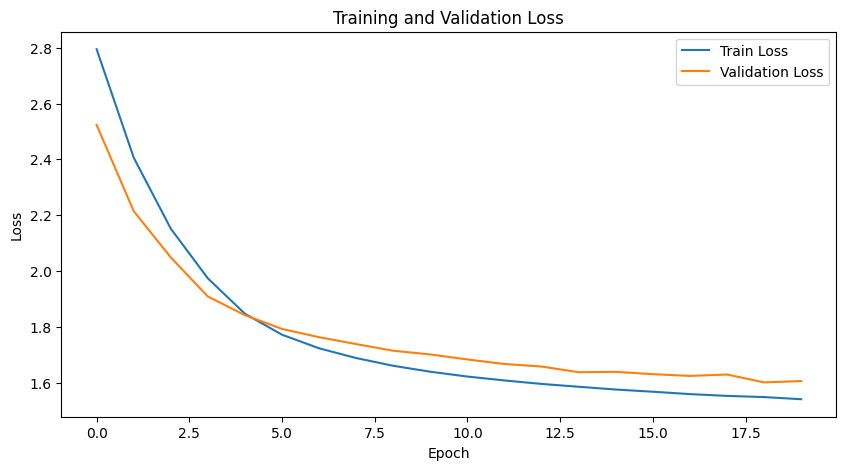

In [118]:
# Plot loss curves
epochs = range(len(slm_model.history['train_loss']))
plt.figure(figsize=(10, 5))
plt.plot(epochs, slm_model.history['train_loss'], label='Train Loss')
plt.plot(epochs, slm_model.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [166]:
# force module reload
import importlib
import src.autoregressive_explorer
importlib.reload(src)
importlib.reload(src.autoregressive_explorer)

<module 'src.autoregressive_explorer' from '/Users/leo/Documents/UNI/SL TA/Torch-Crash-Course/src/autoregressive_explorer/__init__.py'>

In [167]:
from src.autoregressive_explorer import start_explorer
# Start the interactive UI
# (Assuming `slm_model`, `encode`, and `decode` are already defined)
server_thread = start_explorer(
    model=slm_model, 
    encode=encode, 
    decode=decode
)